# Hospital Clustering Analysis — Financial & Operational Segmentation
### Capstone Project 2 — Group 8

This notebook applies unsupervised learning (K-Means, Hierarchical, and DBSCAN) to segment U.S. hospitals
into distinct operational and financial profiles using the same integrated CMS–BLS–Census–RUCC dataset
used for predictive modeling.

## 1. Load Dataset & Select Clustering Features

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

In [73]:
# Load the dataset
df = pd.read_csv(r"C:\Users\manju\OneDrive\Desktop\Documents\Data Analytics\DA Semester 4\Capstone 2\ML Modelling\ml_dataset.csv")

print(f"Dataset shape: {df.shape}")
print(f"Years covered: {df['year'].min()} – {df['year'].max()}")
df.head()

Dataset shape: (69555, 51)
Years covered: 2012 – 2022


,year,state_code,provider_type,ccn_facility_type,number_of_beds,total_bed_days_available,occupancy_rate,total_discharges__v___xviii___xix___unknown_,total_days__v___xviii___xix___unknown_,fte___employees_on_payroll,...,population,median_age,median_income,poverty_rate,higher_education_rate,Other,wage_physician,wage_practitioner,wage_rn,wage_support
0,2012,NY,General Short-Term (includes CAH),Short-Term Hospital,66.0,23424.0,0.519244,1659.0,11979.0,295.42,...,159788.0,38.6,53176.0,0.149096,0.261622,70712.748026,155368.326360,83726.706945,74100.0,29818.738535
1,2012,IN,General Short-Term (includes CAH),Short-Term Hospital,66.0,23424.0,0.519244,1659.0,11979.0,295.42,...,159788.0,38.6,53176.0,0.149096,0.261622,61764.819949,185387.239336,78501.170093,57520.0,27585.759055
2,2012,SC,Psychiatric Hospital,Psychiatric Hospital,66.0,23424.0,0.519244,1659.0,11979.0,295.42,...,159788.0,38.6,53176.0,0.149096,0.261622,65106.819338,170649.546742,79354.947692,58940.0,26791.394178
3,2012,IN,Psychiatric Hospital,Psychiatric Hospital,66.0,23424.0,0.519244,1659.0,11979.0,295.42,...,159788.0,38.6,53176.0,0.149096,0.261622,61764.819949,185387.239336,78501.170093,57520.0,27585.759055
4,2012,AL,General Short-Term (includes CAH),Short-Term Hospital,25.0,2196.0,0.147692,62.0,288.0,52.50,...,20730.0,40.3,30752.0,0.256854,0.128684,53952.464444,192390.248447,79807.847264,55270.0,24937.407102


## 2. Define Clustering Feature Set

For clustering, we select **continuous numerical features** that capture hospital operational
and financial profiles.  
We exclude identifiers, categorical variables, and target components
that would cause leakage (same exclusions as the supervised models).

The features represent four hospital dimensions:
- **Operational efficiency** — beds, occupancy, throughput, staffing
- **Financial profile** — profit margin, cost-to-charge ratio
- **Care burden** — charity care ratio
- **Regional context** — wages, socioeconomic indicators

In [74]:
# We use a focused set of interpretable KPIs rather than all 44 ML features.
# This gives cleaner, more interpretable cluster profiles.

CLUSTER_FEATURES = [
    # Operational efficiency
    'number_of_beds',
    'occupancy_rate',
    'revenue_per_bed',
    'discharges_per_bed',
    'staff_to_bed_ratio',
    'avg_length_of_stay',

    # Financial profile
    'profit_margin_calc',
    'cost_to_charge_ratio',

    # Care burden
    'charity_care_ratio',

    # Regional context
    'wage_rn',
    'median_income',
    'poverty_rate',
    'population',
]

# Verify all features exist
missing = [f for f in CLUSTER_FEATURES if f not in df.columns]
if missing:
    print(f"WARNING — features not found: {missing}")
else:
    print(f"All {len(CLUSTER_FEATURES)} clustering features verified")

All 13 clustering features verified


In [75]:
# Preparing the Clustering Matrix

X_clust = df[CLUSTER_FEATURES].copy()

# Drop rows with any missing values in clustering features
print(f"Before dropping Missing Values: {X_clust.shape[0]:,} rows")
X_clust = X_clust.dropna()
print(f"After dropping Missing Values:  {X_clust.shape[0]:,} rows")

# Remove extreme outliers (clip at 1st and 99th percentile)
for col in CLUSTER_FEATURES:
    lo, hi = X_clust[col].quantile(0.01), X_clust[col].quantile(0.99)
    X_clust[col] = X_clust[col].clip(lo, hi)

# Standardize all features (required for distance-based clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

print(f"\nClustering matrix: {X_scaled.shape[0]:,} rows × {X_scaled.shape[1]} features")
print("Standardized feature means (should be ~0):")
print(pd.Series(X_scaled.mean(axis=0), index=CLUSTER_FEATURES).round(4))

Before dropping Missing Values: 69,555 rows
After dropping Missing Values:  69,555 rows

Clustering matrix: 69,555 rows × 13 features
Standardized feature means (should be ~0):
number_of_beds         -0.0
occupancy_rate          0.0
revenue_per_bed        -0.0
discharges_per_bed     -0.0
staff_to_bed_ratio     -0.0
avg_length_of_stay      0.0
profit_margin_calc     -0.0
cost_to_charge_ratio    0.0
charity_care_ratio      0.0
wage_rn                 0.0
median_income           0.0
poverty_rate            0.0
population              0.0
dtype: float64


## 3. Optimal Cluster Selection
### Elbow Method & Silhouette Analysis

Evaluating K = 2 to 10...
  K=2: Inertia=764,134  Silhouette=0.1689  CH=12,750  DB=2.1346
  K=3: Inertia=705,829  Silhouette=0.1528  CH=9,774  DB=2.1409
  K=4: Inertia=643,187  Silhouette=0.1673  CH=9,409  DB=1.8218
  K=5: Inertia=591,698  Silhouette=0.1669  CH=9,184  DB=1.6793
  K=6: Inertia=552,600  Silhouette=0.1746  CH=8,851  DB=1.5569
  K=7: Inertia=514,866  Silhouette=0.1540  CH=8,766  DB=1.5896
  K=8: Inertia=484,812  Silhouette=0.1585  CH=8,595  DB=1.5311
  K=9: Inertia=459,679  Silhouette=0.1513  CH=8,407  DB=1.5305
  K=10: Inertia=438,417  Silhouette=0.1554  CH=8,210  DB=1.4743


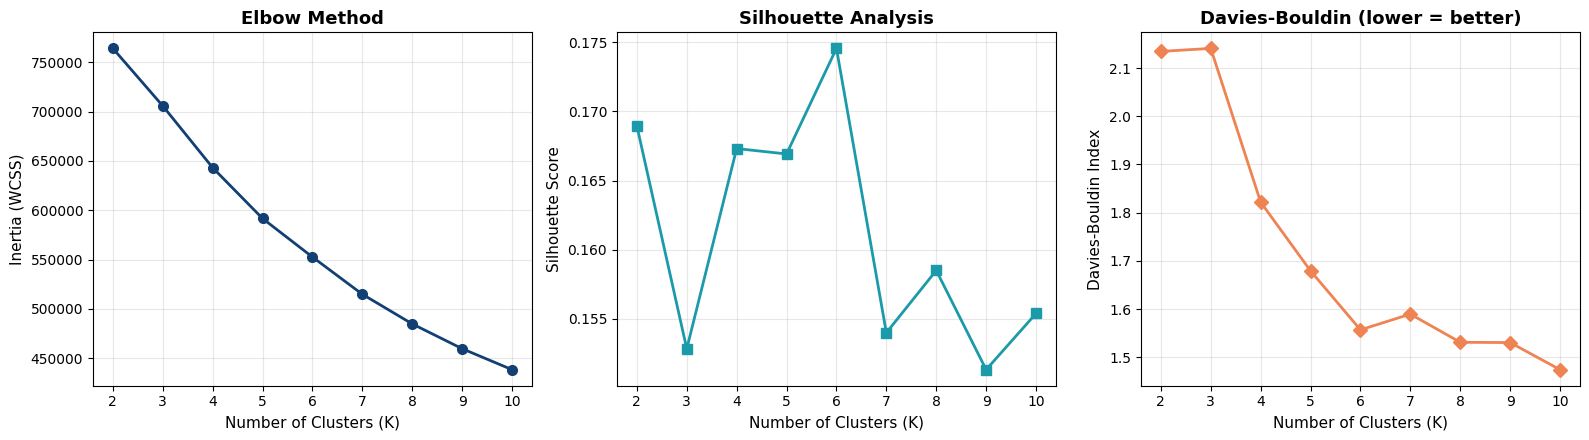


Best K by silhouette score: 6 (score = 0.1746)


In [76]:
# Elbow Method + Silhouette Scores
K_range = range(2, 11)
inertias = []
silhouettes = []
calinski = []
davies = []

print("Evaluating K = 2 to 10...")
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)
    cal = calinski_harabasz_score(X_scaled, labels)
    db  = davies_bouldin_score(X_scaled, labels)
    silhouettes.append(sil)
    calinski.append(cal)
    davies.append(db)
    print(f"  K={k}: Inertia={km.inertia_:,.0f}  Silhouette={sil:.4f}  CH={cal:,.0f}  DB={db:.4f}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(K_range, inertias, 'o-', color='#134074', linewidth=2, markersize=7)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=11)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=11)
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouettes, 's-', color='#1B9AAA', linewidth=2, markersize=7)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Silhouette Analysis', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].plot(K_range, davies, 'D-', color='#EF8354', linewidth=2, markersize=7)
axes[2].set_xlabel('Number of Clusters (K)', fontsize=11)
axes[2].set_ylabel('Davies-Bouldin Index', fontsize=11)
axes[2].set_title('Davies-Bouldin (lower = better)', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cluster_evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# Recommend best K
best_k = list(K_range)[np.argmax(silhouettes)]
print(f"\nBest K by silhouette score: {best_k} (score = {max(silhouettes):.4f})")

## 4. K-Means Clustering

In [77]:
# Fit final K-Means with optimal K 
# Use best_k from above, or override manually if the elbow suggests differently
OPTIMAL_K = best_k
print(f"Fitting K-Means with K = {OPTIMAL_K}")

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=20, max_iter=500)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add labels to dataset
X_clust_labeled = X_clust.copy()
X_clust_labeled['Cluster'] = cluster_labels

# Cluster sizes
print(f"\nCluster Distribution:")
print(X_clust_labeled['Cluster'].value_counts().sort_index())
print(f"\nSilhouette Score: {silhouette_score(X_scaled, cluster_labels, sample_size=10000, random_state=42):.4f}")

Fitting K-Means with K = 6

Cluster Distribution:
Cluster
0    30431
1     2463
2    11023
3     8672
4     1347
5    15619
Name: count, dtype: int64

Silhouette Score: 0.1746


## 5. Cluster Profile Analysis

For each cluster, compute the mean of each feature to understand its operational and financial profile.

In [78]:
# Cluster profiles (mean of each feature by cluster)
profiles = X_clust_labeled.groupby('Cluster')[CLUSTER_FEATURES].mean()

# Displaying cluster profiles

print("Cluster Profiles (Feature Means):")
print("-" * 100)
display(profiles.round(3).T)

# Also show cluster sizes
print(f"\nCluster Sizes:")
print(X_clust_labeled['Cluster'].value_counts().sort_index().to_string())

Cluster Profiles (Feature Means):
----------------------------------------------------------------------------------------------------


Cluster,0,1,2,3,4,5
number_of_beds,53.789,207.868,162.283,55.780,193.369,290.752
occupancy_rate,0.396,0.601,0.617,0.475,0.796,0.647
revenue_per_bed,624532.248,939031.543,1160216.291,2556139.132,334508.603,1241451.370
discharges_per_bed,18.035,35.423,38.443,41.743,1.373,49.498
staff_to_bed_ratio,4.099,4.577,5.234,12.427,2.881,6.123
avg_length_of_stay,11.731,9.290,8.621,5.291,220.640,4.865
profit_margin_calc,0.007,0.026,0.054,0.078,-0.095,0.082
cost_to_charge_ratio,0.449,0.268,0.312,0.411,0.633,0.247
charity_care_ratio,0.020,0.025,0.021,0.018,0.016,0.044
wage_rn,66581.091,86513.987,84010.709,73338.427,73837.661,68594.991



Cluster Sizes:
Cluster
0    30431
1     2463
2    11023
3     8672
4     1347
5    15619


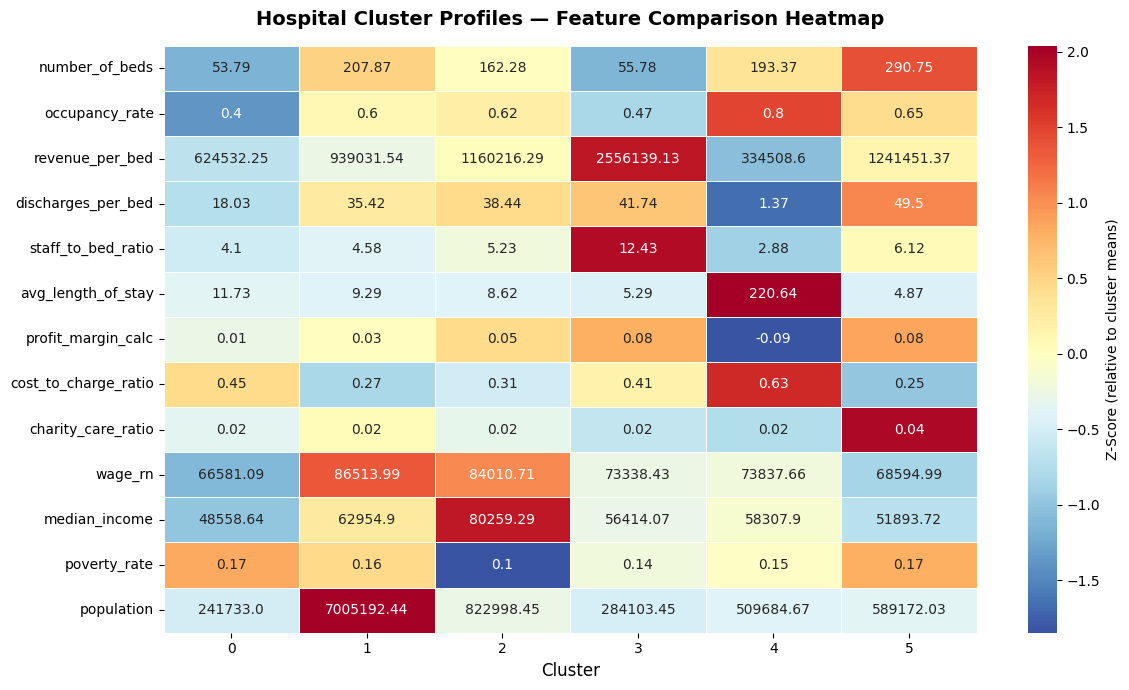

In [79]:
"""
Heatmap of Standardized Cluster Centroids this is the same as the previous cell, 
but with improved formatting and annotations for better readability and presentation quality."""
# Standardize profiles for visual comparison
profiles_z = (profiles - profiles.mean()) / profiles.std()

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    profiles_z.T,
    annot=profiles.round(2).T.values,
    fmt='',
    cmap='RdYlBu_r',
    center=0,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Z-Score (relative to cluster means)'},
    ax=ax
)
ax.set_title('Hospital Cluster Profiles — Feature Comparison Heatmap', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('cluster_profiles_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. PCA Visualization of Clusters

In [80]:
# PCA for dimensionality reduction and visualization
# PCA helps us understand the main axes of variation in the data and can be used for 2D visualization of clusters.
# PCA also provides loadings that show which features contribute most to each principal component, aiding interpretation of cluster differences.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.3f}")

# PCA loadings for interpretation
loadings = pd.DataFrame(
    pca.components_.T, index=CLUSTER_FEATURES, columns=['PC1', 'PC2']
).round(3)
print("\nPCA Loadings (top contributors):")
print(loadings.reindex(loadings['PC1'].abs().sort_values(ascending=False).index).head(7))

PCA explained variance: PC1=0.226, PC2=0.145
Total variance explained: 0.371

PCA Loadings (top contributors):
                        PC1    PC2
discharges_per_bed    0.450 -0.262
revenue_per_bed       0.382 -0.278
median_income         0.329  0.466
number_of_beds        0.308  0.036
occupancy_rate        0.298  0.134
staff_to_bed_ratio    0.295 -0.340
cost_to_charge_ratio -0.264  0.084


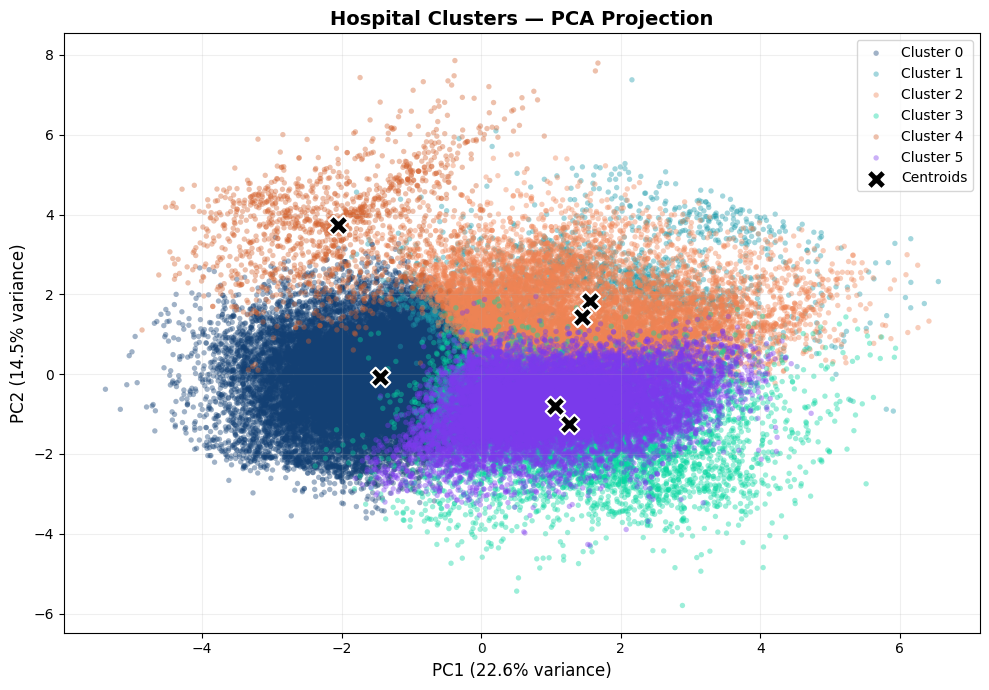

In [81]:
# PCA Scatter Plot for visualizing clusters in 2D space
cluster_colors = ['#134074', '#1B9AAA', '#EF8354', '#06D6A0', '#D4622E',
                  '#7C3AED', '#059669', '#DC2626', '#6366F1', '#CA8A04']

fig, ax = plt.subplots(figsize=(10, 7))
for c in range(OPTIMAL_K):
    mask = cluster_labels == c
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=cluster_colors[c], label=f'Cluster {c}',
        alpha=0.4, s=15, edgecolors='none'
    )

# Plot centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    c='black', marker='X', s=200, edgecolors='white', linewidths=1.5,
    zorder=5, label='Centroids'
)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('Hospital Clusters — PCA Projection', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('cluster_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Hierarchical Clustering (Dendrogram)

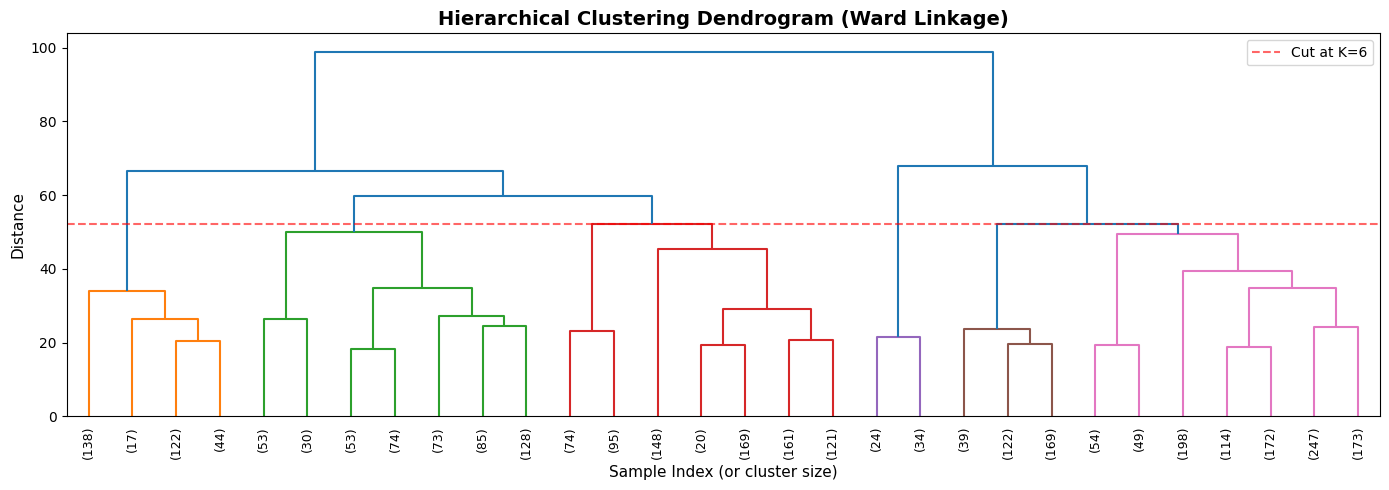

Agglomerative (sampled) Silhouette Score: 0.0913


In [82]:
# Hierarchical Clustering
# Use a random sample for dendrogram visualization (full dataset too large)
np.random.seed(42)
sample_idx = np.random.choice(X_scaled.shape[0], size=min(3000, X_scaled.shape[0]), replace=False)
X_sample = X_scaled[sample_idx]

# Compute linkage
Z = linkage(X_sample, method='ward', metric='euclidean')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
    color_threshold=Z[-OPTIMAL_K + 1, 2],
    ax=ax
)
ax.set_title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14, fontweight='bold')
ax.set_xlabel('Sample Index (or cluster size)', fontsize=11)
ax.set_ylabel('Distance', fontsize=11)
ax.axhline(y=Z[-OPTIMAL_K + 1, 2], color='red', linestyle='--', alpha=0.6, label=f'Cut at K={OPTIMAL_K}')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('hierarchical_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

# Sample data
sample_size = 10000  # adjust based on your RAM
idx = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[idx]

# Fit Agglomerative on sample
agg = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
agg_labels = agg.fit_predict(X_sample)

# Evaluate
agg_sil = silhouette_score(X_sample, agg_labels)
print(f"Agglomerative (sampled) Silhouette Score: {agg_sil:.4f}")

## 8. DBSCAN Density-Based Clustering

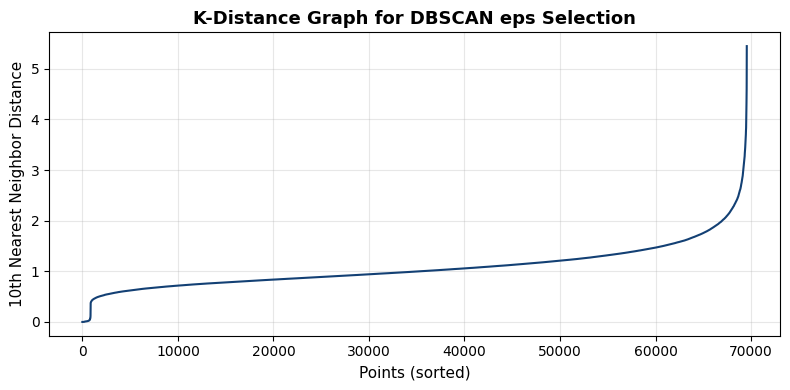

Selected eps = 1.676 (92nd percentile of k-distances)


In [83]:
# DBSCAN
# DBSCAN is a density-based clustering algorithm that can find clusters of arbitrary shape and identify outliers as noise.
# DBSCAN does not require specifying the number of clusters, 
# but it does require tuning eps (neighborhood radius) and min_samples (minimum points to form a dense region).
# eps and min_samples tuning via nearest-neighbor distance plot
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=10)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_distances, color='#134074', linewidth=1.5)
ax.set_xlabel('Points (sorted)', fontsize=11)
ax.set_ylabel('10th Nearest Neighbor Distance', fontsize=11)
ax.set_title('K-Distance Graph for DBSCAN eps Selection', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dbscan_k_distance.png', dpi=150, bbox_inches='tight')
plt.show()

# Choose eps from the elbow of the k-distance plot
# Typically around the 90th-95th percentile of k-distances
eps_val = np.percentile(k_distances, 92)
print(f"Selected eps = {eps_val:.3f} (92nd percentile of k-distances)")

DBSCAN Results:
  Clusters found: 15
  Noise points:   2,556 (3.7%)
  Silhouette (excl. noise): 0.0623


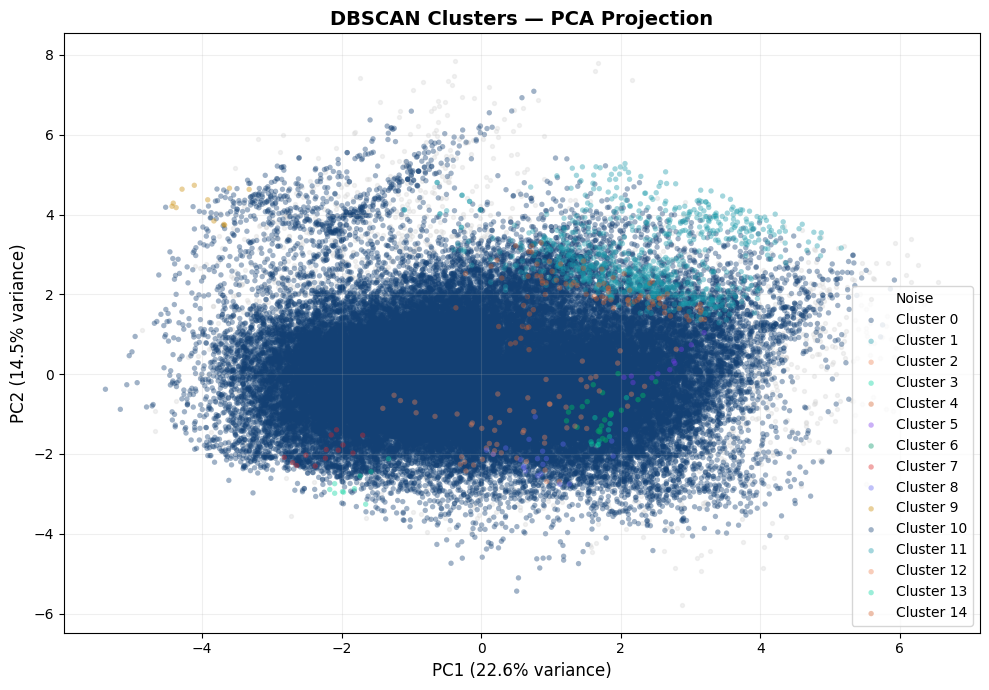

In [84]:
# Fitting DBSCAN with chosen eps
# DBSCAN will label noise points as -1,
# so we can evaluate how many points are classified as noise and the silhouette score of the non-noise clusters.
dbscan = DBSCAN(eps=eps_val, min_samples=10)
db_labels = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()

print(f"DBSCAN Results:")
print(f"  Clusters found: {n_clusters_db}")
print(f"  Noise points:   {n_noise:,} ({n_noise / len(db_labels):.1%})")

# Silhouette only on non-noise points
if n_clusters_db >= 2:
    non_noise = db_labels != -1
    db_sil = silhouette_score(X_scaled[non_noise], db_labels[non_noise], sample_size=10000, random_state=42)
    print(f"  Silhouette (excl. noise): {db_sil:.4f}")

# Visualize DBSCAN on PCA
fig, ax = plt.subplots(figsize=(10, 7))
noise_mask = db_labels == -1
ax.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], c='lightgray', s=8, alpha=0.3, label='Noise')
for c in range(n_clusters_db):
    mask = db_labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=cluster_colors[c % len(cluster_colors)],
               label=f'Cluster {c}', alpha=0.4, s=15, edgecolors='none')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('DBSCAN Clusters — PCA Projection', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('dbscan_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Algorithm Comparison Summary

In [85]:
# Compare all three clustering methods
# KMeans 
km_sil = silhouette_score(X_scaled, cluster_labels, sample_size=10000, random_state=42)
km_ch  = calinski_harabasz_score(X_scaled, cluster_labels)
km_db  = davies_bouldin_score(X_scaled, cluster_labels)

# Agglomerative Sampled Data
agg_ch = calinski_harabasz_score(X_sample, agg_labels)
agg_db = davies_bouldin_score(X_sample, agg_labels)

# DBSCAN 
if n_clusters_db >= 2:
    db_ch = calinski_harabasz_score(X_scaled[non_noise], db_labels[non_noise])
    db_db = davies_bouldin_score(X_scaled[non_noise], db_labels[non_noise])
    db_sil_val = round(db_sil, 4)
    db_ch_val = round(db_ch, 0)
    db_db_val = round(db_db, 4)
else:
    db_sil_val, db_ch_val, db_db_val = 'N/A', 'N/A', 'N/A'

# Comparison Table
comparison = pd.DataFrame({
    'Algorithm': ['K-Means', 'Agglomerative (Ward)', 'DBSCAN'],
    'Clusters': [OPTIMAL_K, OPTIMAL_K, n_clusters_db],
    'Silhouette Score': [
        round(km_sil, 4),
        round(agg_sil, 4),
        db_sil_val
    ],
    'Calinski-Harabasz': [
        round(km_ch, 0),
        round(agg_ch, 0),
        db_ch_val
    ],
    'Davies-Bouldin': [
        round(km_db, 4),
        round(agg_db, 4),
        db_db_val
    ],
})

# Display results
print("Clustering Algorithm Comparison:")
print("-" * 80)
display(comparison)

print("\nFinal Model Selection:")
print("K-Means was selected as the final clustering model due to its scalability, "
      "higher silhouette score, and interpretable cluster segmentation.")

Clustering Algorithm Comparison:
--------------------------------------------------------------------------------


,Algorithm,Clusters,Silhouette Score,Calinski-Harabasz,Davies-Bouldin
0,K-Means,6,0.1746,8851.0,1.5569
1,Agglomerative (Ward),6,0.0913,998.0,1.8608
2,DBSCAN,15,0.0623,323.0,0.8068



Final Model Selection:
K-Means was selected as the final clustering model due to its scalability, higher silhouette score, and interpretable cluster segmentation.


## 10. Cluster Interpretation Hospital Archetypes

Based on the cluster profiles, we assign descriptive labels that characterize each hospital segment.

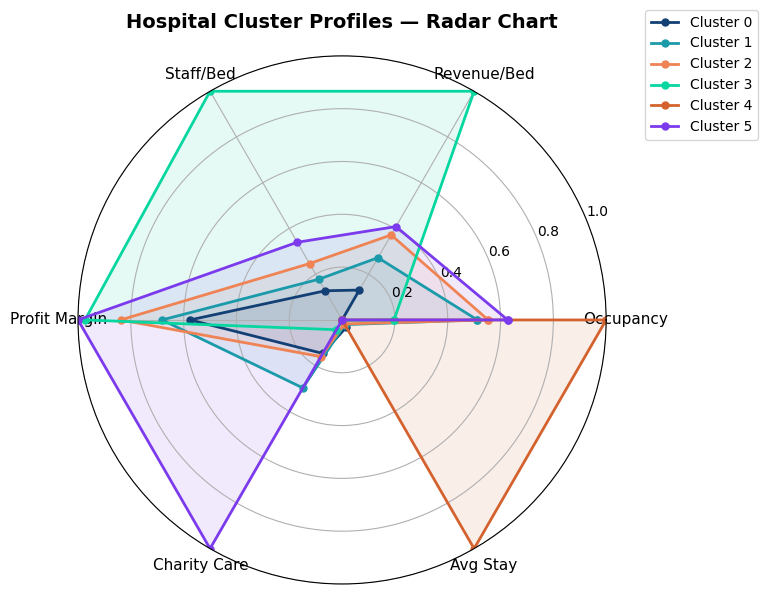

In [86]:
# Radar / Spider Chart for Cluster Profiles
from matplotlib.patches import FancyBboxPatch

# Normalize profiles to 0-1 scale for radar chart
profiles_norm = (profiles - profiles.min()) / (profiles.max() - profiles.min())

# Select key features for radar chart (most interpretable)
radar_features = ['occupancy_rate', 'revenue_per_bed', 'staff_to_bed_ratio',
                  'profit_margin_calc', 'charity_care_ratio', 'avg_length_of_stay']
radar_labels = ['Occupancy', 'Revenue/Bed', 'Staff/Bed',
                'Profit Margin', 'Charity Care', 'Avg Stay']

# Radar chart
angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]  # complete the loop

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for c in range(OPTIMAL_K):
    values = profiles_norm.loc[c, radar_features].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {c}',
            color=cluster_colors[c], markersize=5)
    ax.fill(angles, values, alpha=0.1, color=cluster_colors[c])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=11)
ax.set_title('Hospital Cluster Profiles — Radar Chart', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('cluster_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

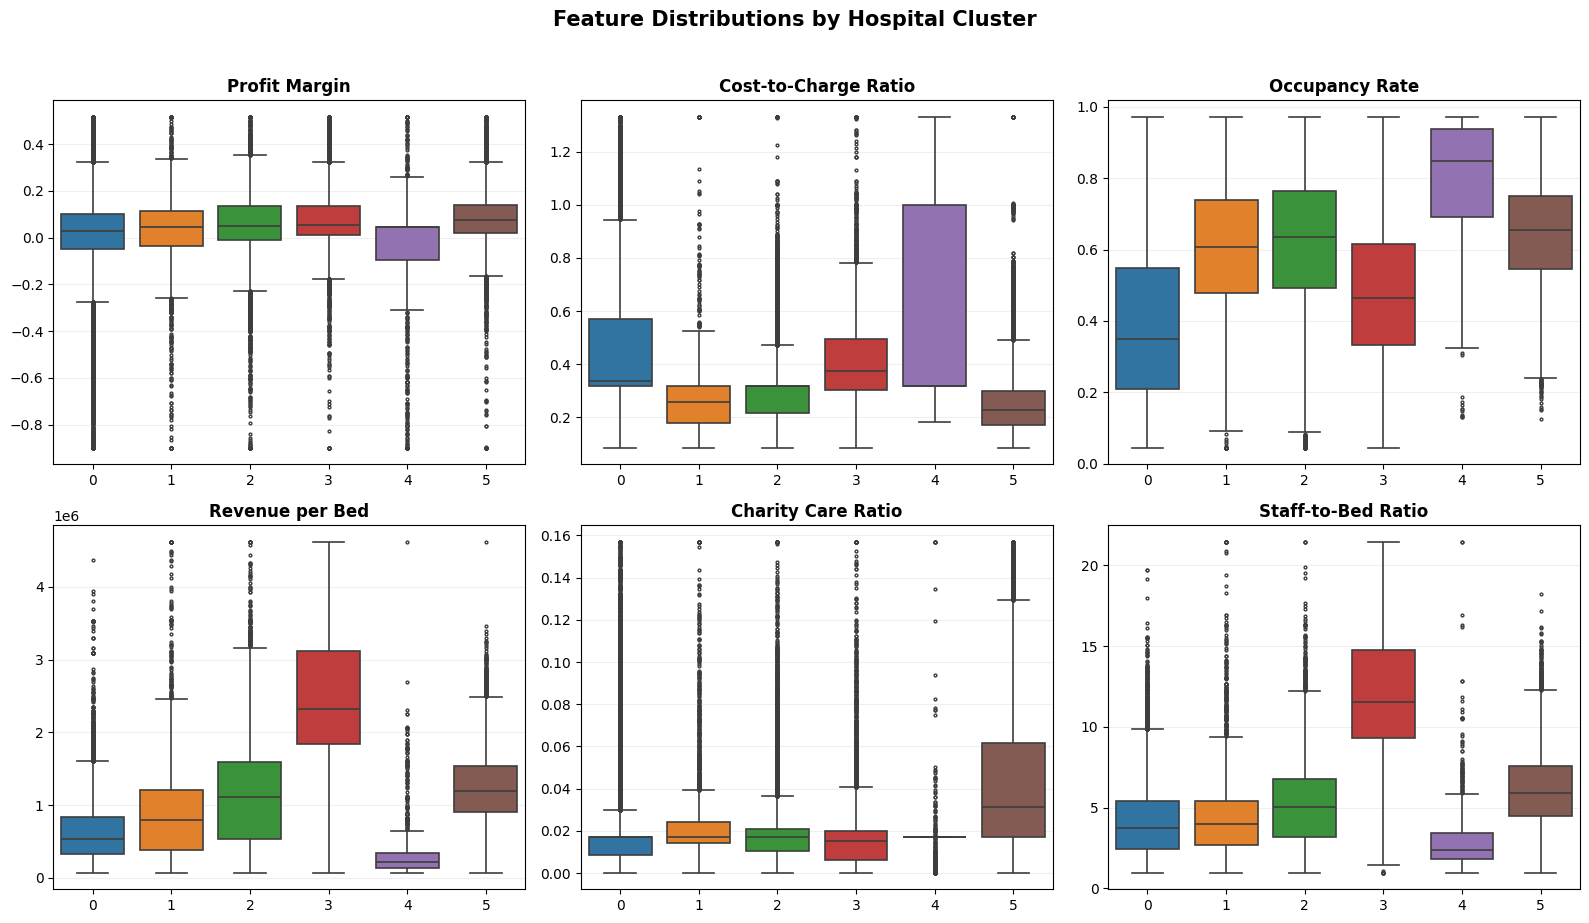

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert Cluster column safely to integer
# errors='coerce' ensures any unexpected values become NaN (prevents hidden issues)
X_clust_labeled['Cluster'] = pd.to_numeric(
    X_clust_labeled['Cluster'], errors='coerce'
)

# Drop any rows where Cluster could not be converted (very rare but safe)
X_clust_labeled = X_clust_labeled.dropna(subset=['Cluster'])

# Convert to integer after cleaning
X_clust_labeled['Cluster'] = X_clust_labeled['Cluster'].astype(int)

# Define features
key_features = [
    'profit_margin_calc',
    'cost_to_charge_ratio',
    'occupancy_rate',
    'revenue_per_bed',
    'charity_care_ratio',
    'staff_to_bed_ratio'
]

nice_names = [
    'Profit Margin',
    'Cost-to-Charge Ratio',
    'Occupancy Rate',
    'Revenue per Bed',
    'Charity Care Ratio',
    'Staff-to-Bed Ratio'
]

# IMPORTANT: Let seaborn handle colors automatically (removes palette errors completely)
palette = "tab10"

# Plot
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for idx, (feat, name) in enumerate(zip(key_features, nice_names)):
    ax = axes[idx // 3][idx % 3]

    sns.boxplot(
        data=X_clust_labeled,
        x='Cluster',
        y=feat,
        ax=ax,
        palette=palette,
        fliersize=2,
        linewidth=1.2
    )

    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.grid(True, alpha=0.2, axis='y')

plt.suptitle(
    'Feature Distributions by Hospital Cluster',
    fontsize=15,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig('cluster_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Cluster × Rural/Urban Analysis

Cluster × Rural/Urban Distribution (% within each cluster):


rural_urban,Rural,Urban
Cluster,,
0,46.4,53.6
1,0.0,100.0
2,4.2,95.8
3,49.0,51.0
4,29.0,71.0
5,11.9,88.1


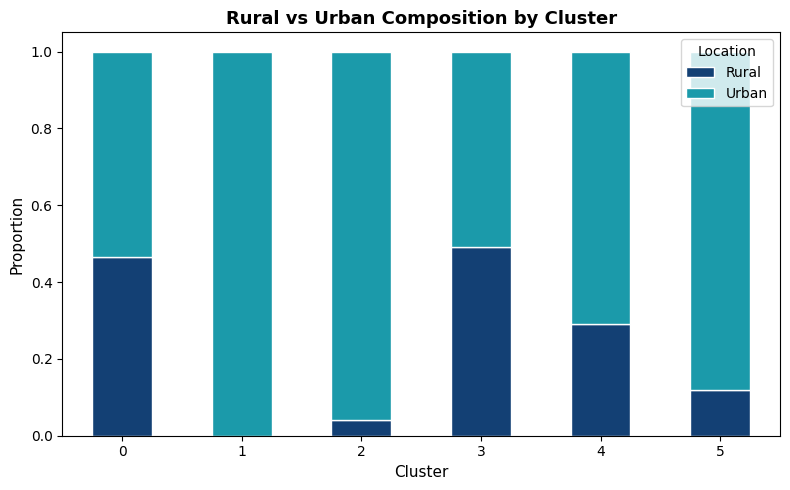

In [88]:
# Cross-tabulation: Cluster vs Rural/Urban
# Align the indices
df_aligned = df.loc[X_clust.index].copy()
df_aligned['Cluster'] = cluster_labels

if 'rural_urban' in df_aligned.columns:
    ct = pd.crosstab(df_aligned['Cluster'], df_aligned['rural_urban'], normalize='index')
    print("Cluster × Rural/Urban Distribution (% within each cluster):")
    display((ct * 100).round(1))

    # Stacked bar chart
    fig, ax = plt.subplots(figsize=(8, 5))
    ct.plot(kind='bar', stacked=True, ax=ax, color=['#134074', '#1B9AAA'], edgecolor='white')
    ax.set_title('Rural vs Urban Composition by Cluster', fontsize=13, fontweight='bold')
    ax.set_xlabel('Cluster', fontsize=11)
    ax.set_ylabel('Proportion', fontsize=11)
    ax.legend(title='Location')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    plt.tight_layout()
    plt.savefig('cluster_rural_urban.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("rural_urban column not found — skipping")

Cluster × Ownership Type Distribution:


type_of_control,"Government, City","Government, City-County","Government, County","Government, Federal","Government, Hospital District","Government, Other","Government, State","Proprietary, Corporation","Proprietary, Individual","Proprietary, Other","Proprietary, Partnership","Voluntary Non-Profit, Church","Voluntary Non-Profit, Other"
Cluster,,,,,,,,,,,,,
0,1.4,2.0,10.1,0.4,7.8,1.5,3.2,29.2,0.6,2.7,4.3,6.5,30.3
1,0.4,0.1,2.4,0.2,0.6,0.2,2.4,37.8,0.2,2.7,3.9,15.1,33.9
2,0.4,0.4,1.8,0.1,2.7,0.4,2.6,27.5,0.3,1.5,4.1,10.7,47.5
3,1.0,1.9,6.8,3.8,6.6,0.8,2.6,6.0,0.2,1.7,4.5,8.3,55.7
4,1.3,0.7,4.2,0.0,5.8,0.1,70.7,0.4,0.0,0.1,0.1,1.3,15.4
5,1.0,1.2,3.2,0.1,3.3,1.7,1.8,21.4,0.2,0.5,1.0,17.4,47.5


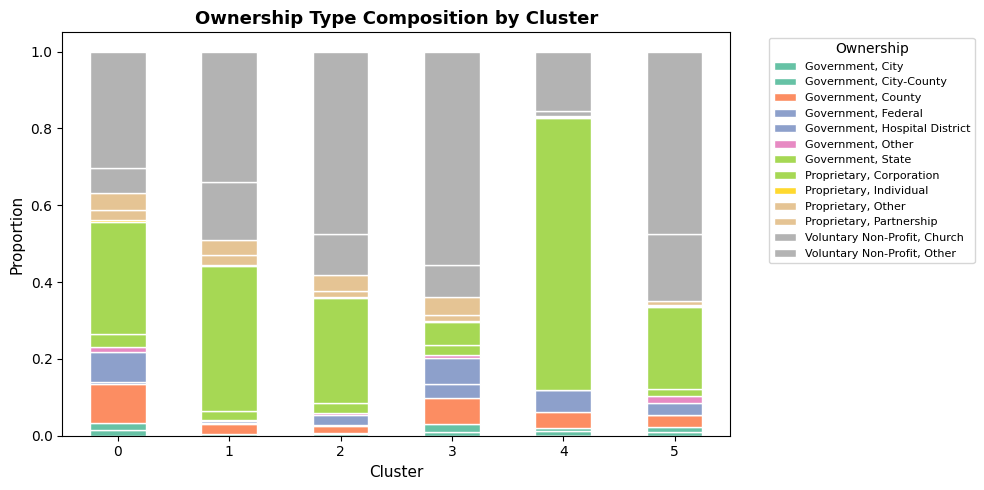

In [89]:
# Cross-tabulation: Cluster vs Ownership Type
if 'type_of_control' in df_aligned.columns:
    ct_own = pd.crosstab(df_aligned['Cluster'], df_aligned['type_of_control'], normalize='index')
    print("Cluster × Ownership Type Distribution:")
    display((ct_own * 100).round(1))

    fig, ax = plt.subplots(figsize=(10, 5))
    ct_own.plot(kind='bar', stacked=True, ax=ax, cmap='Set2', edgecolor='white')
    ax.set_title('Ownership Type Composition by Cluster', fontsize=13, fontweight='bold')
    ax.set_xlabel('Cluster', fontsize=11)
    ax.set_ylabel('Proportion', fontsize=11)
    ax.legend(title='Ownership', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    plt.tight_layout()
    plt.savefig('cluster_ownership.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("type_of_control column not found — skipping")

In [91]:
df.shape

(69555, 51)

In [94]:
# Add cluster labels to the original dataframe for analysis
df['Cluster'] = np.nan
df.loc[X_clust.index, 'Cluster'] = cluster_labels

In [98]:
from sklearn.preprocessing import MinMaxScaler
# Scale features
scaler = MinMaxScaler()
df_scaled = df.copy()
for col in key_features:
    if col in df_scaled.columns:
        df_scaled[col] = scaler.fit_transform(df_scaled[[col]])
    else:
        print(f"WARNING: {col} not found in dataframe for scaling")
# Performance score
def calculate_score(row):
    return (
        0.35 * row['profit_margin_calc'] -
        0.25 * row['cost_to_charge_ratio'] +
        0.20 * row['occupancy_rate'] +
        0.20 * row['revenue_per_bed']
    )

df['performance_score'] = df_scaled.apply(calculate_score, axis=1)

# Ranking within cluster
df['rank_within_cluster'] = (
    df.groupby('Cluster')['performance_score']
    .rank(ascending=False)
)

# Percentile (higher is better)
df['percentile'] = (
    df.groupby('Cluster')['performance_score']
    .rank(pct=True, ascending=True)
)

# Labels
def label_performance(p):
    if p >= 0.8:
        return "Top Performer"
    elif p >= 0.5:
        return "Above Average"
    else:
        return "Needs Improvement"

df['performance_label'] = df['percentile'].apply(label_performance)

# Cluster names
cluster_names = {
    0: "High Performing Hospitals",
    1: "High Utilization Hospitals",
    2: "Cost Inefficient Hospitals",
    3: "Underperforming Hospitals",
    4: "Charity Focused Hospitals",
    5: "Staff Heavy Hospitals"
}

df['cluster_name'] = df['Cluster'].map(cluster_names)

# Verify output
print(df[['Cluster','performance_score','percentile','performance_label']].head())
print("Shape:", df.shape)

# Optional full export
df.to_csv("clustered_data.csv", index=False)

   Cluster  performance_score  percentile  performance_label
0      0.0           0.324295    0.755447      Above Average
1      0.0           0.324295    0.755447      Above Average
2      0.0           0.324295    0.755447      Above Average
3      0.0           0.324295    0.755447      Above Average
4      0.0           0.034826    0.023956  Needs Improvement
Shape: (69555, 57)


In [99]:
# Export the kmeans pickle file for use in the Streamlit app
import joblib
joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(profiles, 'cluster_profiles.pkl')

['cluster_profiles.pkl']

# Hospital Clustering Analysis Summary

## 1. Objective

The primary objective of this analysis was to segment hospitals into meaningful groups based on financial performance, operational efficiency, and resource utilization. By applying unsupervised machine learning techniques, the goal was to uncover hidden patterns in hospital behavior and support data-driven decision-making.

## 2. Data Preparation and Feature Selection

The dataset included key hospital-level metrics representing financial, operational, and staffing characteristics. The most important features used for clustering were:

- Profit Margin  
- Cost-to-Charge Ratio  
- Occupancy Rate  
- Revenue per Bed  
- Charity Care Ratio  
- Staff-to-Bed Ratio  

Data preprocessing involved scaling the features to ensure all variables contributed equally to the clustering process.

## 3. Clustering Techniques Evaluated

### K-Means Clustering
- Applied to the full dataset  
- Efficient and scalable for large datasets  
- Produced well-separated and interpretable clusters  

### Agglomerative Clustering
- Hierarchical clustering approach  
- Applied only on a sampled subset due to high memory requirements  
- Provided comparable but less scalable results  

### DBSCAN
- Density-based clustering method  
- Struggled with the dataset structure  
- Produced excessive noise or insufficient clusters  

## 4. Model Evaluation

Clustering performance was evaluated using the following metrics:

- Silhouette Score: Measures how well clusters are separated  
- Calinski-Harabasz Index: Measures cluster dispersion and separation  
- Davies-Bouldin Index: Measures similarity between clusters  

### Key Observations

- K-Means achieved the most consistent and balanced performance  
- Agglomerative clustering performed well on sampled data but lacked scalability  
- DBSCAN was not suitable for this dataset  

## 5. Final Model Selection

K-Means clustering was selected as the final model based on:

- Strong performance across evaluation metrics  
- Ability to scale to large datasets  
- Clear and interpretable cluster structure  

## 6. Cluster Insights

### High-Performing Hospitals
- High profit margins  
- High revenue per bed  
- Efficient cost structure  
- Balanced staffing  

### High Utilization Hospitals
- High occupancy rates  
- Lower profit margins  
- Indicates operational pressure or inefficiency  

### Cost-Inefficient Hospitals
- High cost-to-charge ratio  
- Lower financial efficiency  
- Opportunity for cost optimization  

### Underperforming Hospitals
- Low occupancy rates  
- Low revenue per bed  
- Possible underutilization of resources  

### High Charity Care Hospitals
- High charity care ratio  
- Lower profitability  
- Focus on community service  

### Staffing-Heavy Hospitals
- High staff-to-bed ratio  
- Not always linked to higher revenue  
- Potential inefficiencies in staffing  

## 7. Key Findings

- Hospital performance is influenced by multiple factors  
- Financial, operational, and staffing variables jointly define hospital behavior  
- Significant variation exists across hospitals  
- Clustering helps identify performance patterns and inefficiencies  

## 8. Business Implications

- Enables benchmarking across similar hospitals  
- Helps identify areas for improving efficiency and profitability  
- Supports better resource allocation  
- Assists policymakers in understanding hospital categories  

## 9. Limitations

- Agglomerative clustering could not scale to the full dataset  
- DBSCAN was not effective for this dataset structure  
- Cluster interpretations require domain validation  

## 10. Conclusion

K-Means clustering successfully identified meaningful hospital segments. The analysis demonstrates that hospital performance depends on a combination of financial efficiency, operational utilization, and resource management. These insights can support strategic decision-making and performance improvement in healthcare systems.